# 2024년 서울 공공자전거(따릉이) 월별 이용 분석
- 데이터: 2024년도 1월~12월 자료(2401_merge.csv ~ 2412_merge.csv)
- 컬럼: 대여일시, 대여 대여소명, 반납일시, 반납 대여소명, 대여자치구, 반납 자치구, 대여요일

# 설정

In [1]:
import os, glob, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
warnings.filterwarnings('ignore')


In [2]:
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

In [4]:
DATA_DIR = r"C:\ai\source\09_project\00_data\24"      
OUT_DIR  = r"C:\ai\source\09_project\01_output\24" 
os.makedirs(OUT_DIR, exist_ok=True)

In [5]:
SEASON_ORDER = ['봄', '여름', '가을', '겨울']
SEASON_COLOR = {'봄': '#8BC34A', '여름': '#FF7043', '가을': '#FFB300', '겨울': '#42A5F5'}
WEEKDAY_ORDER = ['월', '화', '수', '목', '금', '토', '일']
MONTH_LABEL = [f'{m}월' for m in range(1, 13)]


In [6]:
def to_season(m):
    return {12: '겨울', 1: '겨울', 2: '겨울', 3: '봄', 4: '봄', 5: '봄',
            6: '여름', 7: '여름', 8: '여름'}.get(m, '가을')
def save(name):
    plt.savefig(os.path.join(OUT_DIR, name), dpi=150, bbox_inches='tight')


In [7]:
files = sorted(glob.glob(os.path.join(DATA_DIR, '24??_merge.csv')))
print('파일 수:', len(files), [os.path.basename(f) for f in files])
pd.read_csv(files[0], encoding='utf-8-sig', nrows=3)

파일 수: 12 ['2401_merge.csv', '2402_merge.csv', '2403_merge.csv', '2404_merge.csv', '2405_merge.csv', '2406_merge.csv', '2407_merge.csv', '2408_merge.csv', '2409_merge.csv', '2410_merge.csv', '2411_merge.csv', '2412_merge.csv']


,대여일시,대여 대여소명,반납일시,반납 대여소명,대여자치구,반납 자치구,대여요일
0,2024-01-01 00:04:10,동서울농협 앞,2024-01-01 00:05:13,상봉역 3번출구,중랑구,중랑구,월
1,2024-01-01 00:03:13,군자역 7번출구 베스트샵 앞,2024-01-01 00:06:33,세종사이버대학교,광진구,광진구,월
2,2024-01-01 00:03:02,동묘앞역 6번출구,2024-01-01 00:07:33,맥스타일 앞,종로구,중구,월


#  월별 파일 -> 집계표

In [8]:
print('현재 작업 폴더:', os.getcwd())
print('DATA_DIR:', os.path.abspath(DATA_DIR))
print('폴더 존재?', os.path.isdir(DATA_DIR))
print(os.listdir(DATA_DIR) if os.path.isdir(DATA_DIR) else '폴더 없음')

현재 작업 폴더: C:\ai\source\09_project
DATA_DIR: C:\ai\source\09_project\00_data\24
폴더 존재? True
['2401_merge.csv', '2402_merge.csv', '2403_merge.csv', '2404_merge.csv', '2405_merge.csv', '2406_merge.csv', '2407_merge.csv', '2408_merge.csv', '2409_merge.csv', '2410_merge.csv', '2411_merge.csv', '2412_merge.csv']


In [9]:
DUR_BINS   = [0, 5, 10, 20, 30, 60, 120, 240]
DUR_LABELS = ['5분 이하', '5~10분', '10~20분', '20~30분', '30~60분', '1~2시간', '2~4시간']

def aggregate_month(path):
    t = time.time()
    df = pd.read_csv(path, encoding='utf-8-sig',
                     usecols=['대여일시', '반납일시', '대여 대여소명', '대여자치구', '반납 자치구'])
    df['대여일시'] = pd.to_datetime(df['대여일시'], errors='coerce')   # 1월 파일은 초 없음 → 자동 인식
    df['반납일시'] = pd.to_datetime(df['반납일시'], errors='coerce')
    df = df.dropna(subset=['대여일시'])
    df['date']  = df['대여일시'].dt.normalize()
    df['hour']  = df['대여일시'].dt.hour
    df['month'] = df['대여일시'].dt.month
    df['이용시간'] = (df['반납일시'] - df['대여일시']).dt.total_seconds() / 60
    out = {}
    out['hourly'] = df.groupby(['대여자치구', 'date', 'hour']).size().reset_index(name='cnt')
    out['od'] = df.groupby(['month', '대여자치구', '반납 자치구']).size().reset_index(name='cnt')
    out['station'] = df.groupby(['month', '대여 대여소명', '대여자치구']).size().reset_index(name='cnt')

    valid = df[(df['이용시간'] > 0) & (df['이용시간'] <= 240)]
    out['duration'] = (valid.groupby(['month', '대여자치구'])['이용시간']
                            .agg(['sum', 'count', 'median']).reset_index())
    bins = pd.cut(valid['이용시간'], bins=DUR_BINS, labels=DUR_LABELS)
    out['dur_bin'] = (valid.groupby([valid['month'], bins], observed=False)
                           .size().reset_index(name='cnt'))
    out['dur_bin'].columns = ['month', '구간', 'cnt']
    print(f'{os.path.basename(path)}: {len(df):,}건, {time.time() - t:.1f}초')
    return out

parts = [aggregate_month(f) for f in files]
agg = {k: pd.concat([p[k] for p in parts], ignore_index=True) for k in parts[0]}
del parts

for k, v in agg.items():                      # 집계표 저장 → 다음부터는 아래 셀로 바로 불러오기
    v.to_csv(os.path.join(OUT_DIR, f'agg_{k}.csv'), index=False, encoding='utf-8-sig')
print({k: v.shape for k, v in agg.items()})

2401_merge.csv: 1,309,237건, 4.8초
2402_merge.csv: 1,341,620건, 4.7초
2403_merge.csv: 2,094,029건, 7.5초
2404_merge.csv: 3,057,404건, 10.4초
2405_merge.csv: 3,214,837건, 9.9초
2406_merge.csv: 3,283,078건, 11.6초
2407_merge.csv: 2,531,401건, 8.9초
2408_merge.csv: 2,716,086건, 8.1초
2409_merge.csv: 2,883,163건, 10.1초
2410_merge.csv: 3,200,697건, 11.6초
2411_merge.csv: 2,406,110건, 8.3초
2412_merge.csv: 1,577,621건, 5.6초
{'hourly': (219278, 4), 'od': (6649, 4), 'station': (32783, 4), 'duration': (300, 5), 'dur_bin': (84, 3)}


# 파생변수
- 월, 계절, 요일, 평일/주말
- daily(구 × 날짜), city_daily(서울 전체 × 날짜), city_hourly(서울 전체 × 날짜 × 시간)

In [10]:
def add_date_features(df):
    df = df.copy()
    df['month']   = df['date'].dt.month
    df['season']  = df['month'].map(to_season)
    df['weekday'] = df['date'].dt.dayofweek.map(dict(enumerate(WEEKDAY_ORDER)))
    df['daytype'] = np.where(df['date'].dt.dayofweek >= 5, '주말', '평일')
    return df

hourly      = add_date_features(agg['hourly'])
daily       = add_date_features(hourly.groupby(['대여자치구', 'date'], as_index=False)['cnt'].sum())
city_daily  = add_date_features(hourly.groupby('date', as_index=False)['cnt'].sum())
city_hourly = add_date_features(hourly.groupby(['date', 'hour'], as_index=False)['cnt'].sum())

print(f"총 이용 {hourly['cnt'].sum():,}건 / 자치구 {daily['대여자치구'].nunique()}개 / "
      f"기간 {city_daily['date'].min().date()} ~ {city_daily['date'].max().date()} ({len(city_daily)}일)")

총 이용 29,615,283건 / 자치구 25개 / 기간 2024-01-01 ~ 2024-12-31 (366일)


# 월별 총이용량과 전월대비 증감율

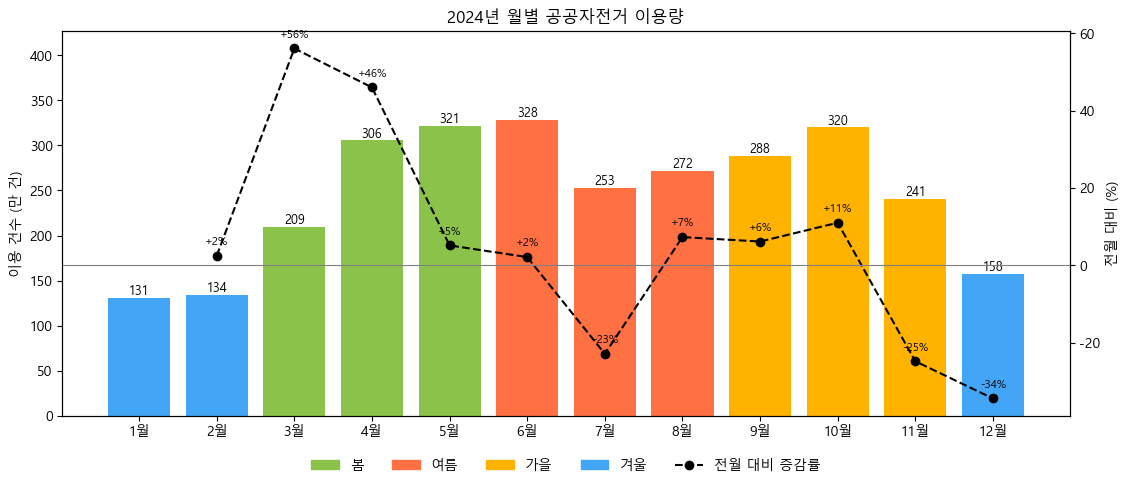

,month,total,days,daily_mean,mom_pct,season
0,1,1309237,31,42233,NaN,겨울
1,2,1341620,29,46263,2.473425,겨울
2,3,2094029,31,67549,56.082125,봄
3,4,3057404,30,101913,46.005810,봄
4,5,3214837,31,103704,5.149238,봄
5,6,3283078,30,109436,2.122689,여름
6,7,2531401,31,81658,-22.895496,여름
7,8,2716086,31,87616,7.295762,여름
8,9,2883163,30,96105,6.151388,가을
9,10,3200697,31,103248,11.013391,가을


In [27]:
monthly = city_daily.groupby('month').agg(total=('cnt', 'sum'), days=('cnt', 'size'),
                                          daily_mean=('cnt', 'mean')).reset_index()
monthly['daily_mean'] = monthly['daily_mean'].round().astype(int)
monthly['mom_pct'] = monthly['total'].pct_change() * 100          # 전월 대비 증감률
monthly['season']  = monthly['month'].map(to_season)

fig, ax1 = plt.subplots(figsize=(13, 5))
bars = ax1.bar(monthly['month'], monthly['total'] / 10000,
               color=monthly['season'].map(SEASON_COLOR))
ax1.bar_label(bars, fmt='%.0f', fontsize=9)
ax1.set_ylabel('이용 건수 (만 건)')
ax1.set_xticks(range(1, 13)); ax1.set_xticklabels(MONTH_LABEL)

ax2 = ax1.twinx()                                                  # 오른쪽 축: 증감률
ax2.plot(monthly['month'], monthly['mom_pct'], 'k--o', lw=1.5, label='전월 대비 증감률')
ax2.axhline(0, color='gray', lw=0.8)
ax2.set_ylabel('전월 대비 (%)')
for m, p in zip(monthly['month'], monthly['mom_pct']): # 전월 대비 증감률(Month-over-Month Percentage)
    if pd.notna(p):
        ax2.annotate(f'{p:+.0f}%', (m, p), xytext=(0, 8), textcoords='offset points',
                     ha='center', fontsize=8)
handles = [Patch(color=c, label=s) for s, c in SEASON_COLOR.items()] + ax2.get_legend_handles_labels()[0]
ax1.set_ylim(0, monthly['total'].max() / 10000 * 1.3)
ax1.legend(handles=handles, ncol=5, loc='upper center', bbox_to_anchor=(0.5, -0.08), frameon=False)
ax1.set_title('2024년 월별 공공자전거 이용량')
save('01_월별총이용량.png'); plt.show()
monthly

In [ ]:
# mom_pct : 전월 대비 증감률(Month-over-Month Percentage)
# daily_mean : 하루 동안 측정된 데이터 값들의 산술 평균

# 월별 일평균 
- 달마다 날짜수가 달라서 일평균으로 비교
- EX : 2월29일, 7월 31일.. 

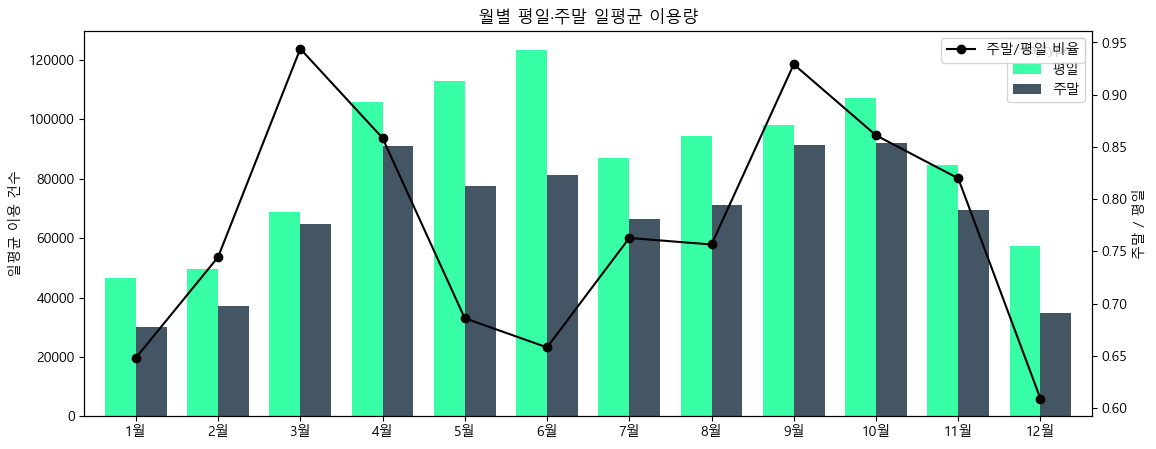

daytype,평일,주말,주말/평일
month,,,
1,46453.17,30101.75,0.65
2,49770.76,37054.25,0.74
3,68793.14,64937.30,0.94
4,105908.00,90928.50,0.86
5,112849.00,77413.75,0.69
6,123512.45,81282.90,0.66
7,86982.22,66351.25,0.76
8,94278.05,71329.89,0.76
9,98195.33,91229.00,0.93


In [12]:
dt_month = city_daily.groupby(['month', 'daytype'])['cnt'].mean().unstack()[['평일', '주말']]
dt_month['주말/평일'] = dt_month['주말'] / dt_month['평일']

ax = dt_month[['평일', '주말']].plot(kind='bar', figsize=(13, 5), color=['#38FFA5', '#445664'], width=0.75)
ax.set_xticklabels(MONTH_LABEL, rotation=0)
ax.set_xlabel(''); ax.set_ylabel('일평균 이용 건수')
ax.set_title('월별 평일·주말 일평균 이용량')
ax2 = ax.twinx()
ax2.plot(range(12), dt_month['주말/평일'].values, 'k-o', label='주말/평일 비율')
ax2.set_ylabel('주말 / 평일'); ax2.legend(loc='upper right')
save('02_월별평일주말.png'); plt.show()
dt_month.round(2)#2FE290

In [ ]:
#sns.palplot(['#38FFA5','#2FE290','#447D64', '#445664'])
# original_color=['#38FFA5','#2FE290','#447D64', '#445664']

# 자치구와 월

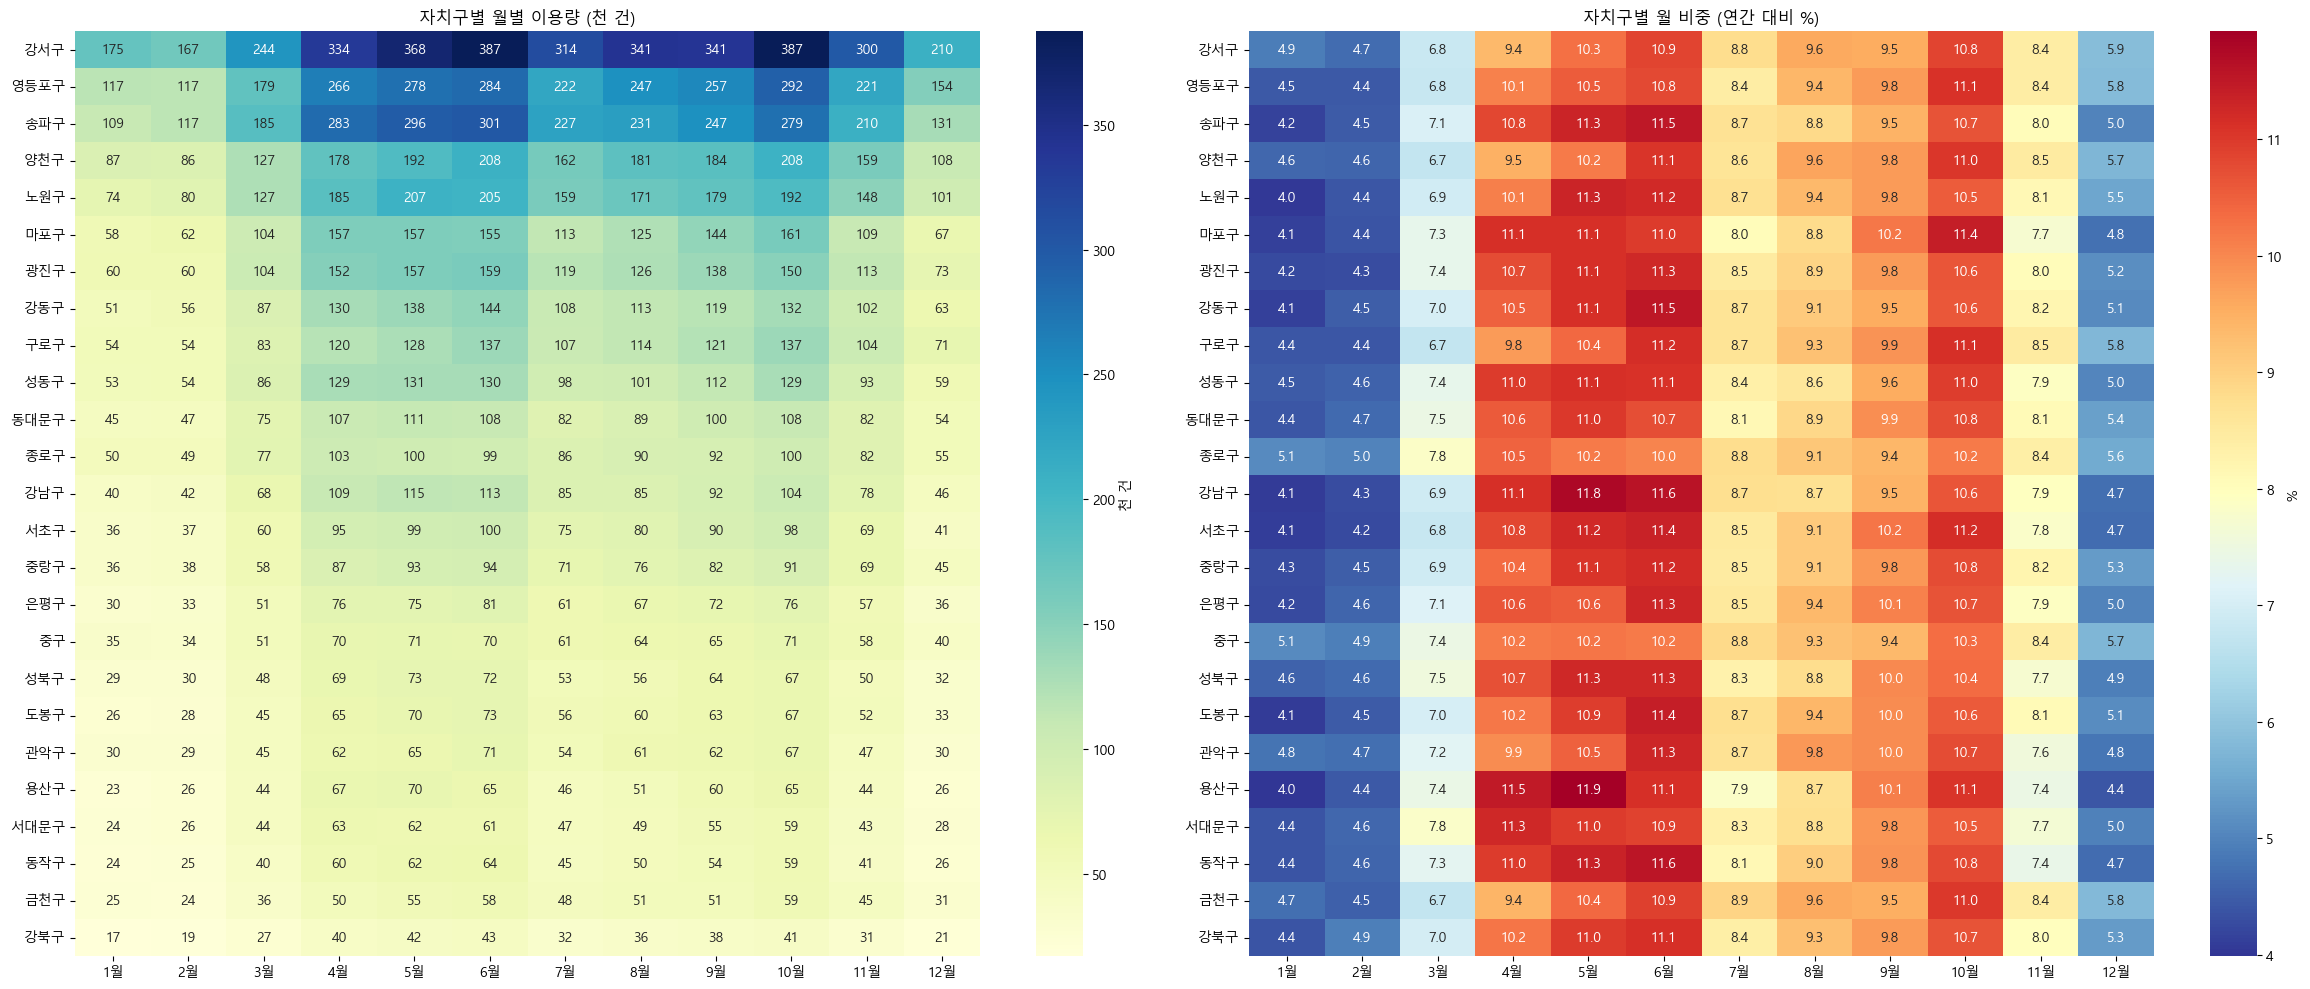

In [13]:
gu_month = hourly.pivot_table(index='대여자치구', columns='month', values='cnt', aggfunc='sum').fillna(0)
gu_month = gu_month.loc[gu_month.sum(axis=1).sort_values(ascending=False).index]
gu_month_ratio = gu_month.div(gu_month.sum(axis=1), axis=0) * 100   # 구별 연간 대비 월 비중

fig, axes = plt.subplots(1, 2, figsize=(24, 10))
sns.heatmap(gu_month / 1000, annot=True, fmt='.0f', cmap='YlGnBu', ax=axes[0], cbar_kws={'label': '천 건'})
axes[0].set_title('자치구별 월별 이용량 (천 건)')
sns.heatmap(gu_month_ratio, annot=True, fmt='.1f', cmap='RdYlBu_r', ax=axes[1], cbar_kws={'label': '%'})
axes[1].set_title('자치구별 월 비중 (연간 대비 %)')
for ax in axes:
    ax.set_xticklabels(MONTH_LABEL, rotation=0); ax.set_xlabel(''); ax.set_ylabel('')
plt.tight_layout(); save('03_자치구월별히트맵.png'); plt.show()

# 이용량 상위 8개 구의 월별 추이와 순위 변화

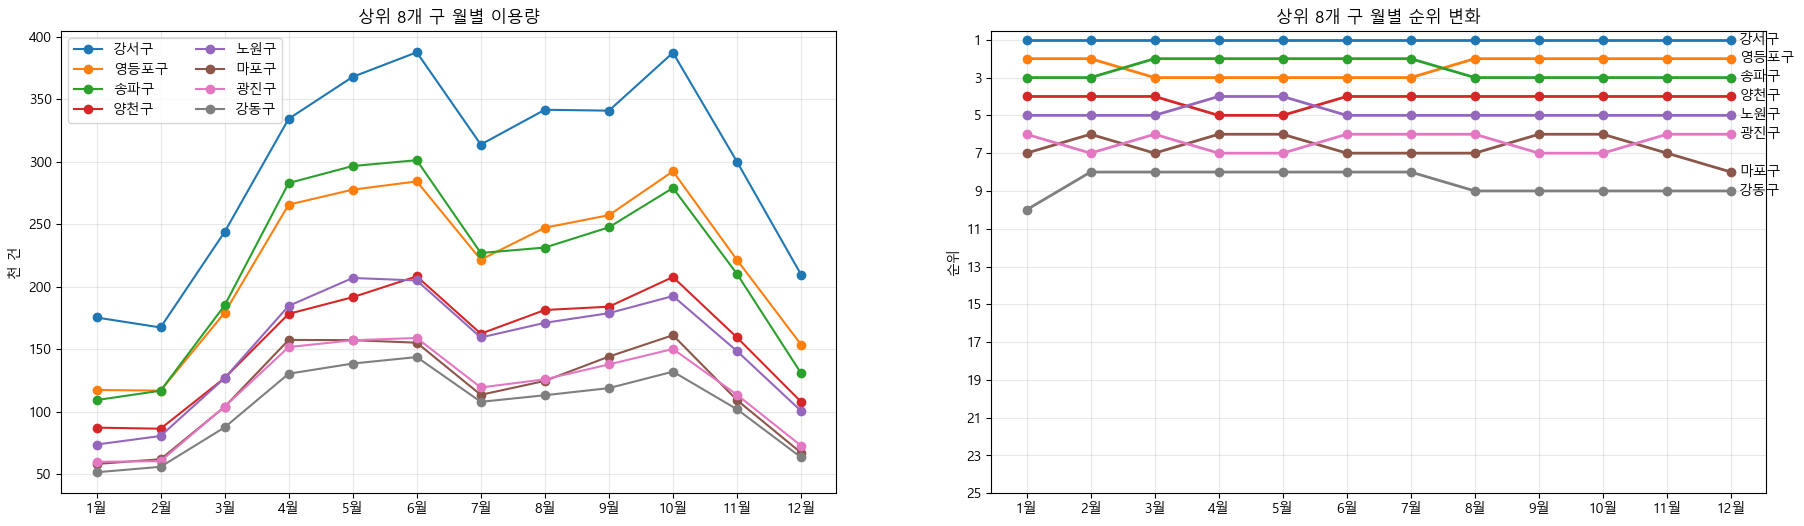

month,1,2,3,4,5,6,7,8,9,10,11,12
대여자치구,,,,,,,,,,,,
강서구,1,1,1,1,1,1,1,1,1,1,1,1
영등포구,2,2,3,3,3,3,3,2,2,2,2,2
송파구,3,3,2,2,2,2,2,3,3,3,3,3
양천구,4,4,4,5,5,4,4,4,4,4,4,4
노원구,5,5,5,4,4,5,5,5,5,5,5,5
마포구,7,6,7,6,6,7,7,7,6,6,7,8
광진구,6,7,6,7,7,6,6,6,7,7,6,6
강동구,10,8,8,8,8,8,8,9,9,9,9,9


In [14]:
top8 = gu_month.index[:8]
rank = gu_month.rank(ascending=False, method='first').astype(int)     # 월별 순위

fig, axes = plt.subplots(1, 2, figsize=(22, 6))
for gu in top8:
    axes[0].plot(range(1, 13), gu_month.loc[gu] / 1000, marker='o', label=gu)
    axes[1].plot(range(1, 13), rank.loc[gu], marker='o', lw=2, label=gu)
    axes[1].annotate(gu, (12, rank.loc[gu, 12]), xytext=(6, 0), textcoords='offset points', va='center')
axes[0].set_title('상위 8개 구 월별 이용량'); axes[0].set_ylabel('천 건'); axes[0].legend(ncol=2)
axes[1].set_title('상위 8개 구 월별 순위 변화'); axes[1].set_ylabel('순위')
axes[1].invert_yaxis(); axes[1].set_yticks(range(1, 26, 2))
for ax in axes:
    ax.set_xticks(range(1, 13)); ax.set_xticklabels(MONTH_LABEL); ax.grid(alpha=0.3)
save('04_상위구추이순위.png'); plt.show()
rank.loc[top8]

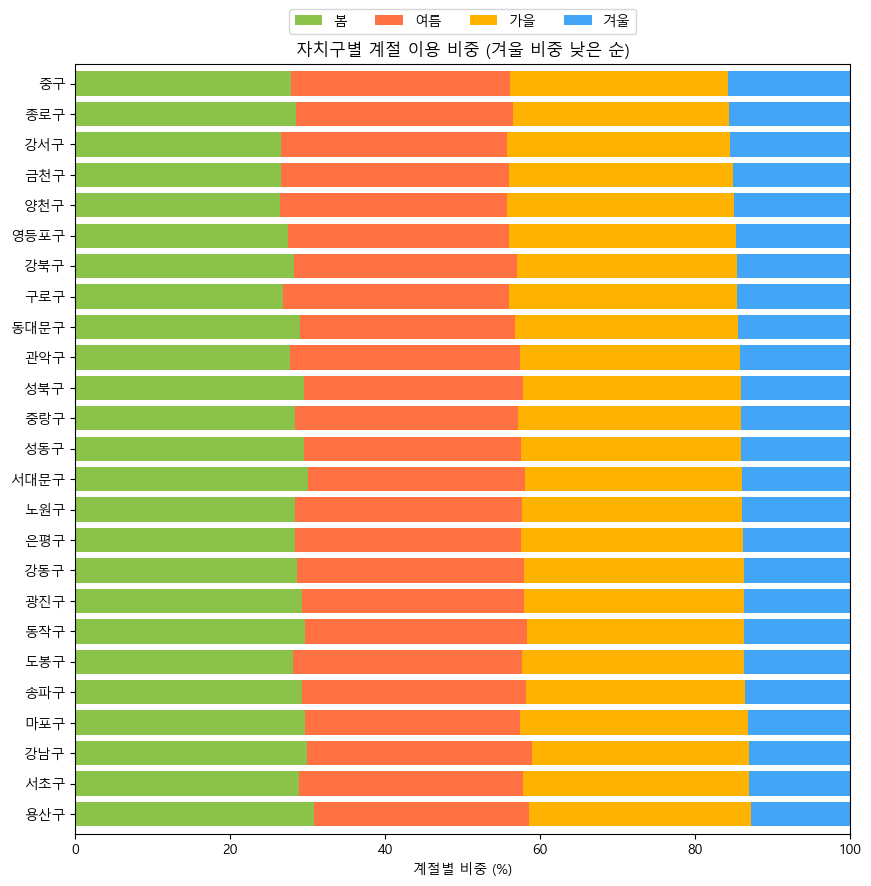

In [15]:
gu_season = daily.pivot_table(index='대여자치구', columns='season', values='cnt', aggfunc='sum')[SEASON_ORDER]
gu_season_ratio = (gu_season.div(gu_season.sum(axis=1), axis=0) * 100).sort_values('겨울')

ax = gu_season_ratio.plot(kind='barh', stacked=True, figsize=(10, 10), width=0.8,
                          color=[SEASON_COLOR[s] for s in SEASON_ORDER])
ax.set_xlim(0, 100); ax.set_xlabel('계절별 비중 (%)'); ax.set_ylabel('')
ax.set_title('자치구별 계절 이용 비중 (겨울 비중 낮은 순)')
ax.legend(ncol=4, loc='lower center', bbox_to_anchor=(0.5, 1.03))
save('05_자치구계절비중.png'); plt.show()

# 시간 패턴 

- 월 X 시간(평일 / 주말)
- 각 칸 = 그달 그시간의 하루 평균 이용건수

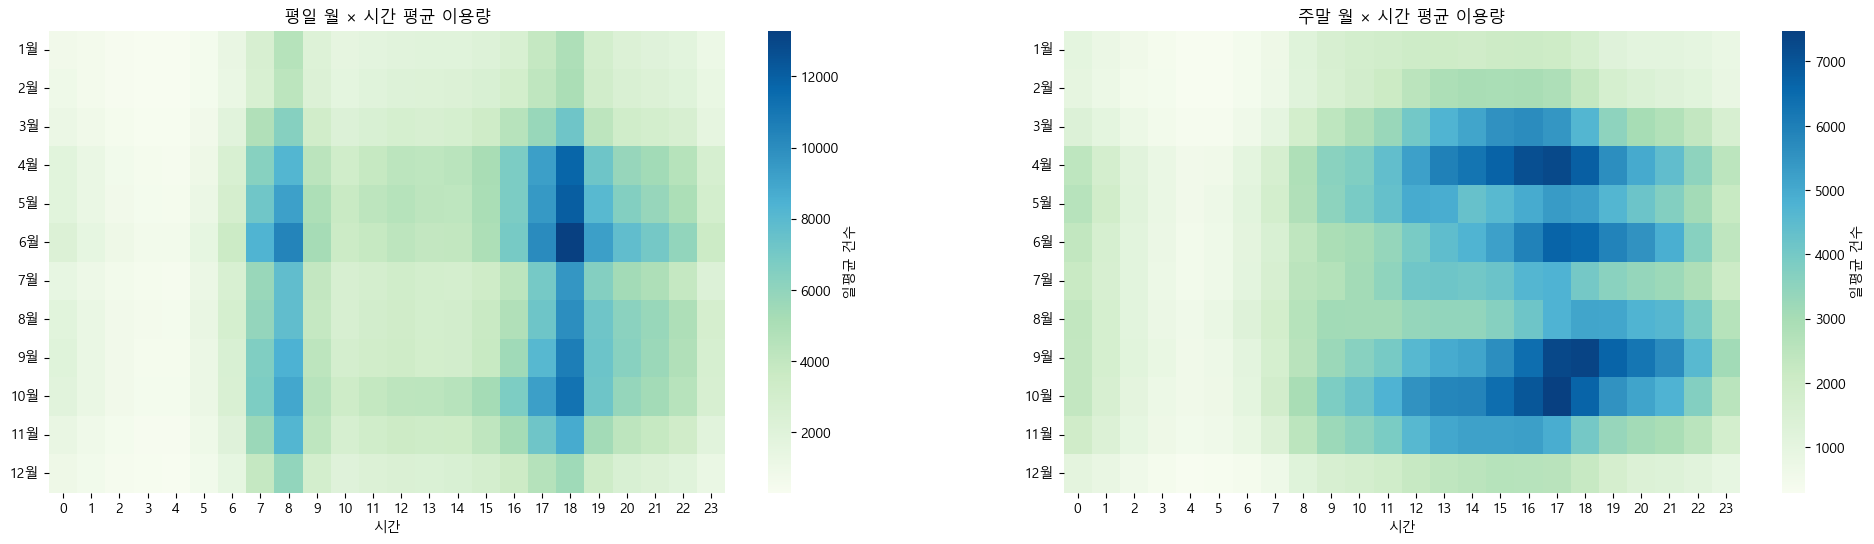

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(24, 6))
for ax, dt in zip(axes, ['평일', '주말']):
    pv = (city_hourly[city_hourly['daytype'] == dt]
          .pivot_table(index='month', columns='hour', values='cnt', aggfunc='mean'))
    sns.heatmap(pv, cmap='GnBu', ax=ax, cbar_kws={'label': '일평균 건수'})
    ax.set_yticklabels(MONTH_LABEL, rotation=0); ax.set_ylabel('')
    ax.set_xlabel('시간'); ax.set_title(f'{dt} 월 × 시간 평균 이용량')
save('06_월시간히트맵.png'); plt.show()

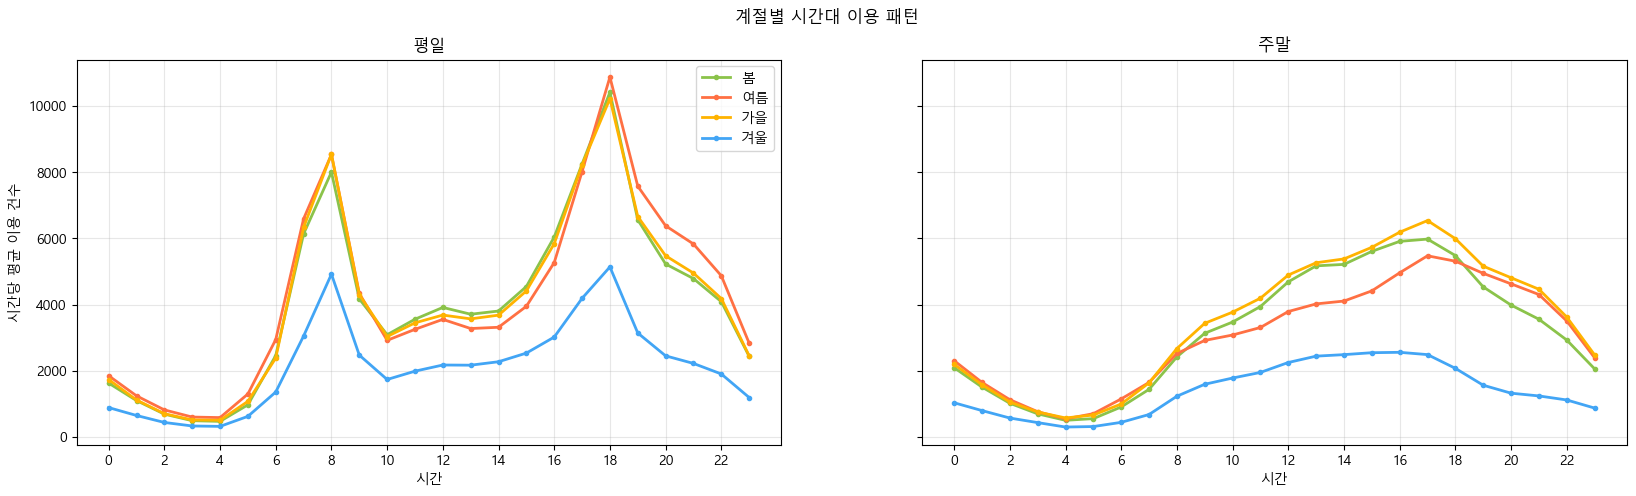

In [17]:
# 계절별 시간대 곡선 (평일/주말)
curve = (city_hourly.groupby(['season', 'daytype', 'hour'])['cnt'].mean().reset_index())
fig, axes = plt.subplots(1, 2, figsize=(20, 5), sharey=True)
for ax, dt in zip(axes, ['평일', '주말']):
    for s in SEASON_ORDER:
        sub = curve[(curve['daytype'] == dt) & (curve['season'] == s)]
        ax.plot(sub['hour'], sub['cnt'], marker='.', color=SEASON_COLOR[s], label=s, lw=2)
    ax.set_title(dt); ax.set_xlabel('시간'); ax.set_xticks(range(0, 24, 2)); ax.grid(alpha=0.3)
axes[0].set_ylabel('시간당 평균 이용 건수'); axes[0].legend()
fig.suptitle('계절별 시간대 이용 패턴')
save('07_계절시간대곡선.png'); plt.show()

# 월 × 요일 (일평균)

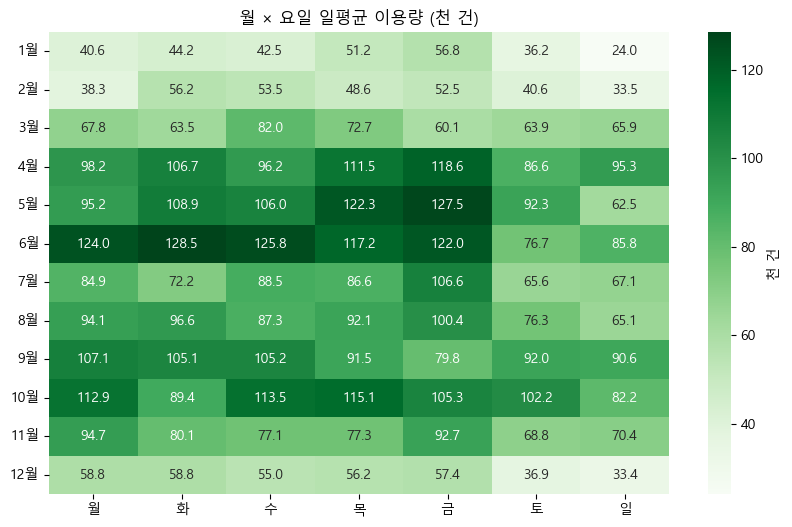

In [18]:
wk = city_daily.pivot_table(index='month', columns='weekday', values='cnt', aggfunc='mean')[WEEKDAY_ORDER]
plt.figure(figsize=(10, 6))
sns.heatmap(wk / 1000, annot=True, fmt='.1f', cmap='Greens', cbar_kws={'label': '천 건'})
plt.yticks(np.arange(12) + 0.5, MONTH_LABEL, rotation=0)
plt.title('월 × 요일 일평균 이용량 (천 건)'); plt.xlabel(''); plt.ylabel('')
save('08_월요일히트맵.png'); plt.show()

# 이용시간 분석

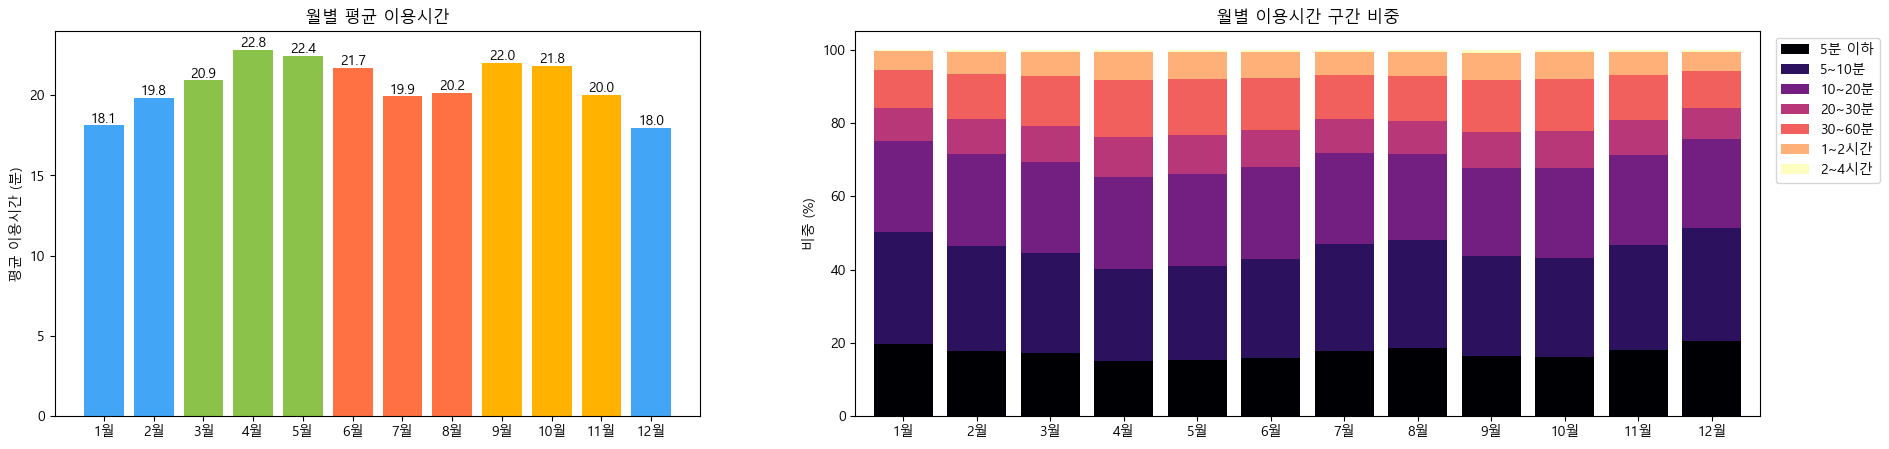

,total,n,평균(분)
month,,,
1,23703902.0,1308740,18.1
2,26594072.6,1341103,19.8
3,43778169.6,2092907,20.9
4,69784325.0,3055511,22.8
5,72124400.2,3212739,22.4
6,71194833.4,3281281,21.7
7,50402502.8,2530036,19.9
8,54741092.7,2714673,20.2
9,63365177.1,2881503,22.0


In [19]:
dur = agg['duration']
dur_month = dur.groupby('month').agg(total=('sum', 'sum'), n=('count', 'sum'))
dur_month['평균(분)'] = dur_month['total'] / dur_month['n']

dur_bin = agg['dur_bin'].pivot_table(index='month', columns='구간', values='cnt', aggfunc='sum')[DUR_LABELS]
dur_bin_ratio = dur_bin.div(dur_bin.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(22, 5), gridspec_kw={'width_ratios': [1, 1.4]})
axes[0].bar(dur_month.index, dur_month['평균(분)'], color=[SEASON_COLOR[to_season(m)] for m in dur_month.index])
axes[0].bar_label(axes[0].containers[0], fmt='%.1f')
axes[0].set_xticks(range(1, 13)); axes[0].set_xticklabels(MONTH_LABEL)
axes[0].set_ylabel('평균 이용시간 (분)'); axes[0].set_title('월별 평균 이용시간')

dur_bin_ratio.plot(kind='bar', stacked=True, ax=axes[1], colormap='magma', width=0.8)
axes[1].set_xticklabels(MONTH_LABEL, rotation=0); axes[1].set_xlabel('')
axes[1].set_ylabel('비중 (%)'); axes[1].set_title('월별 이용시간 구간 비중')
axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left')
save('09_이용시간.png'); plt.show()
dur_month.round(1)

# 이동 패턴 (대여 자치구 → 반납 자치구)

- 같은 구 반납 비율: 동네 안 단거리 이동이 얼마나 되는지
- 순유입 = 그 구에 반납된 건수 − 그 구에서 대여된 건수 → 양수면 자전거가 쌓이는 구, 음수면 빠져나가는 구 (재배치 필요)

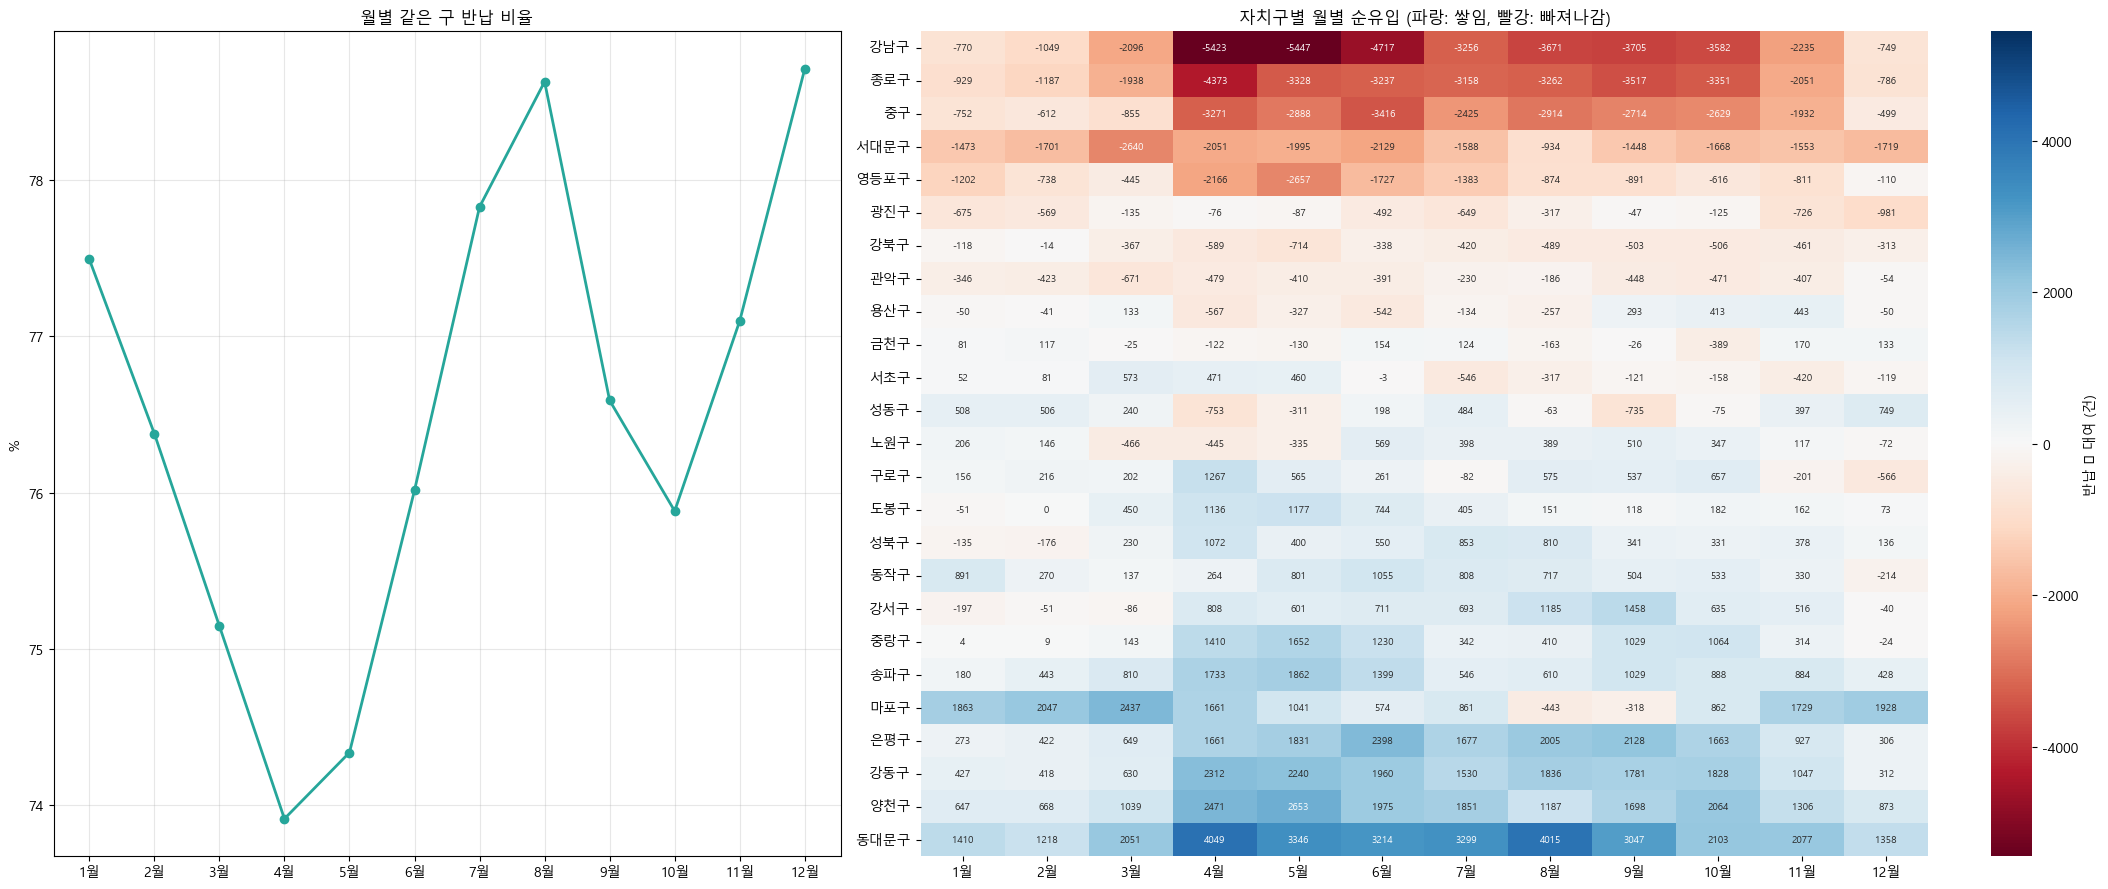

In [20]:
od = agg['od']
same = od.assign(same=od['대여자치구'] == od['반납 자치구']).groupby('month').apply(
    lambda g: g.loc[g['same'], 'cnt'].sum() / g['cnt'].sum() * 100)

out_ = od.groupby(['month', '대여자치구'])['cnt'].sum()
in_  = od.groupby(['month', '반납 자치구'])['cnt'].sum()
in_.index.names = out_.index.names
net = (in_.sub(out_, fill_value=0)).unstack('month')          # 구 × 월 순유입
net = net.loc[net.sum(axis=1).sort_values().index]

fig, axes = plt.subplots(1, 2, figsize=(22, 9), gridspec_kw={'width_ratios': [1, 1.6]})
axes[0].plot(same.index, same.values, 'o-', color='#26A69A', lw=2)
axes[0].set_xticks(range(1, 13)); axes[0].set_xticklabels(MONTH_LABEL)
axes[0].set_ylabel('%'); axes[0].set_title('월별 같은 구 반납 비율'); axes[0].grid(alpha=0.3)
lim = np.abs(net.values).max()
sns.heatmap(net, cmap='RdBu', center=0, vmin=-lim, vmax=lim, annot=True, fmt='.0f',
            annot_kws={'size': 7}, ax=axes[1], cbar_kws={'label': '반납 − 대여 (건)'})
axes[1].set_xticklabels(MONTH_LABEL, rotation=0); axes[1].set_xlabel(''); axes[1].set_ylabel('')
axes[1].set_title('자치구별 월별 순유입 (파랑: 쌓임, 빨강: 빠져나감)')
plt.tight_layout(); save('10_이동패턴.png'); plt.show()

# 인기 대여소 월별 변화

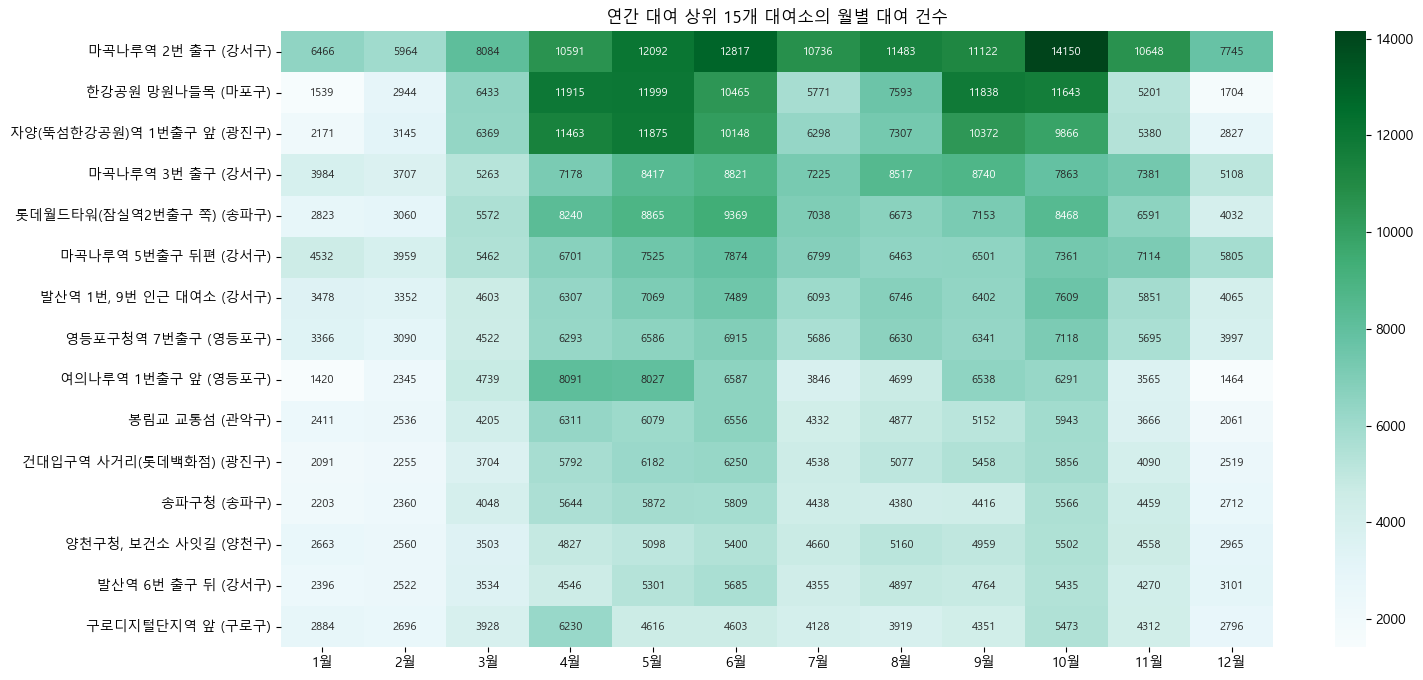

In [21]:
st = agg['station']
st_year = st.groupby(['대여 대여소명', '대여자치구'])['cnt'].sum().sort_values(ascending=False)
top_st = st_year.head(15).index.get_level_values(0)

st_month = (st[st['대여 대여소명'].isin(top_st)]
            .pivot_table(index='대여 대여소명', columns='month', values='cnt', aggfunc='sum')
            .loc[top_st])
st_month.index = [f'{name} ({st_year.loc[name].index[0]})' for name in st_month.index]

plt.figure(figsize=(16, 8))
sns.heatmap(st_month, annot=True, fmt='.0f', cmap='BuGn', annot_kws={'size': 8})
plt.xticks(np.arange(12) + 0.5, MONTH_LABEL, rotation=0)
plt.title('연간 대여 상위 15개 대여소의 월별 대여 건수'); plt.xlabel(''); plt.ylabel('')
save('11_인기대여소.png'); plt.show()

# 통계검정
- 월별 일 이용량 차이: Kruskal-Wallis (정규분포 가정 없음), ANOVA
- 월마다 평일과 주말 일 이용량 차이: Mann-Whitney U
- p-value < 0.05면 "차이가 없다"는 귀무가설 기각

In [22]:
from scipy.stats import kruskal, f_oneway, mannwhitneyu

groups = [g['cnt'].values for _, g in city_daily.groupby('month')]
print('월별 차이  Kruskal-Wallis:', kruskal(*groups))
print('월별 차이  ANOVA         :', f_oneway(*groups))

rows = []
for m, g in city_daily.groupby('month'):
    wd, we = g.loc[g['daytype'] == '평일', 'cnt'], g.loc[g['daytype'] == '주말', 'cnt']
    stat, p = mannwhitneyu(wd, we)
    rows.append({'월': m, '평일 평균': round(wd.mean()), '주말 평균': round(we.mean()),
                 'p-value': round(p, 4), '유의(0.05)': p < 0.05})
pd.DataFrame(rows)

월별 차이  Kruskal-Wallis: KruskalResult(statistic=184.27378375000103, pvalue=1.3429152698784238e-33)
월별 차이  ANOVA         : F_onewayResult(statistic=31.83296195110017, pvalue=1.615972092938844e-46)


,월,평일 평균,주말 평균,p-value,유의(0.05)
0,1,46453,30102,0.0019,True
1,2,49771,37054,0.0927,False
2,3,68793,64937,0.5973,False
3,4,105908,90928,0.0134,True
4,5,112849,77414,0.0004,True
5,6,123512,81283,0.0000,True
6,7,86982,66351,0.0381,True
7,8,94278,71330,0.0003,True
8,9,98195,91229,0.2217,False
9,10,107087,92213,0.0074,True


# 시계열 분해 (statsmodels)
- 일별 이용량 = 추세 + 주간 패턴(period=7) + 나머지
- 추세 곡선의 큰 하락 구간은 기상(장마, 한파)이나 사회적 요인과 비교해 해석합니다.


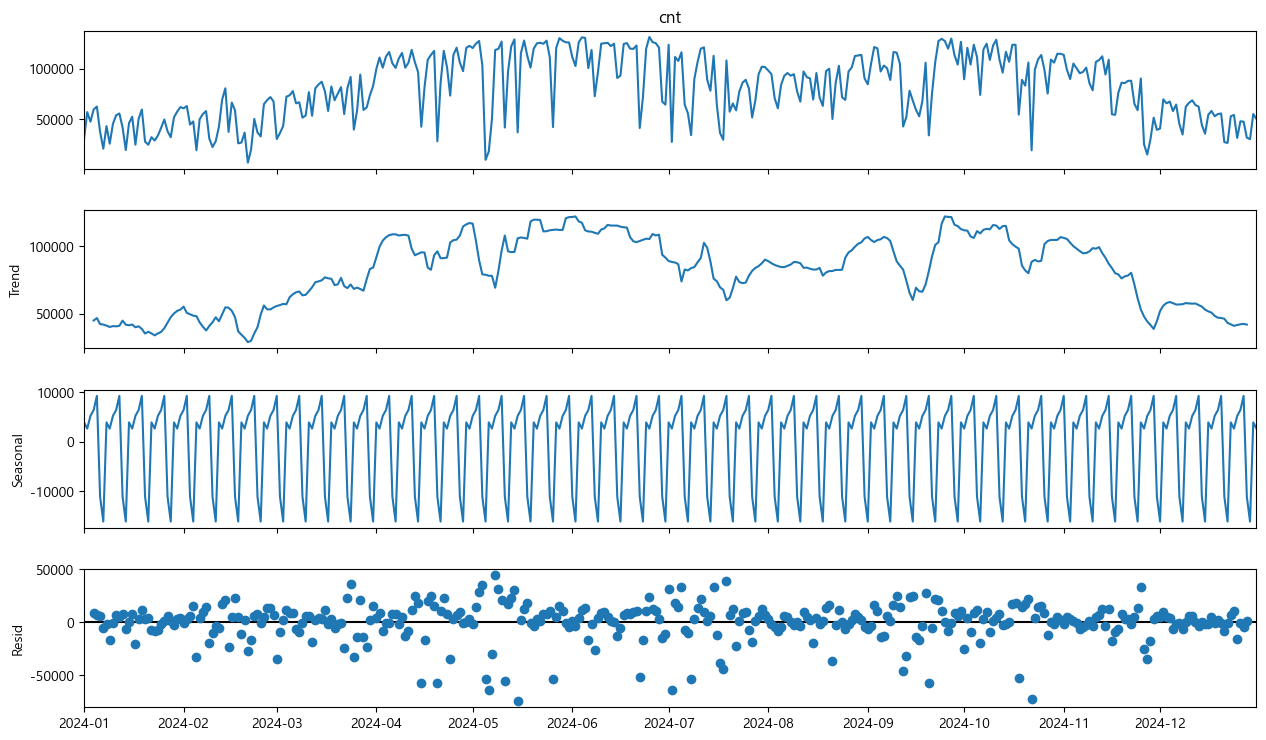

In [23]:
from statsmodels.tsa.seasonal import seasonal_decompose

ts = city_daily.set_index('date')['cnt'].asfreq('D').fillna(0)
result = seasonal_decompose(ts, model='additive', period=7)
fig = result.plot(); fig.set_size_inches(14, 8)
save('13_시계열분해.png'); plt.show()

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

X = StandardScaler().fit_transform(gu_month_ratio)
scores = {k: silhouette_score(X, KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X))
          for k in range(2, 7)}
print({k: round(v, 3) for k, v in scores.items()})
best_k = max(scores, key=scores.get)
print('실루엣 계수가 가장 높은 k =', best_k)

{2: 0.326, 3: 0.352, 4: 0.303, 5: 0.304, 6: 0.307}
실루엣 계수가 가장 높은 k = 3


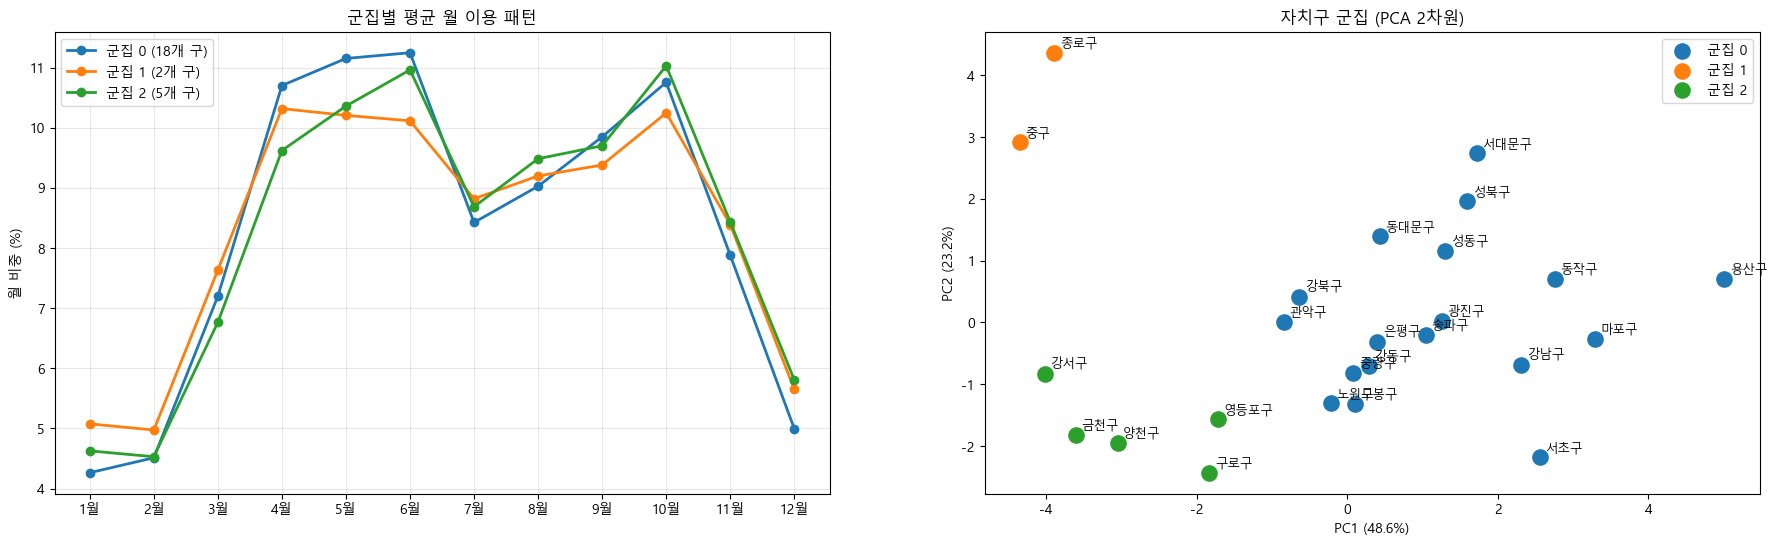

군집 0: 송파구, 노원구, 마포구, 광진구, 강동구, 성동구, 동대문구, 강남구, 서초구, 중랑구, 은평구, 성북구, 도봉구, 관악구, 용산구, 서대문구, 동작구, 강북구
군집 1: 종로구, 중구
군집 2: 강서구, 영등포구, 양천구, 구로구, 금천구


In [25]:
k = best_k                      # 해석이 쉬운 값으로 직접 바꿔도 됨
km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
cluster = pd.Series(km.labels_, index=gu_month_ratio.index, name='cluster')
profile = gu_month_ratio.groupby(cluster).mean()

fig, axes = plt.subplots(1, 2, figsize=(22, 6))
for c, row in profile.iterrows():
    axes[0].plot(range(1, 13), row.values, marker='o', lw=2, label=f'군집 {c} ({(cluster == c).sum()}개 구)')
axes[0].set_xticks(range(1, 13)); axes[0].set_xticklabels(MONTH_LABEL)
axes[0].set_ylabel('월 비중 (%)'); axes[0].set_title('군집별 평균 월 이용 패턴'); axes[0].legend(); axes[0].grid(alpha=0.3)

pca = PCA(n_components=2); xy = pca.fit_transform(X)
for c in range(k):
    axes[1].scatter(xy[cluster.values == c, 0], xy[cluster.values == c, 1], s=120, label=f'군집 {c}')
for (x, y), name in zip(xy, gu_month_ratio.index):
    axes[1].annotate(name, (x, y), xytext=(4, 4), textcoords='offset points', fontsize=9)
ev = pca.explained_variance_ratio_
axes[1].set_xlabel(f'PC1 ({ev[0]:.1%})'); axes[1].set_ylabel(f'PC2 ({ev[1]:.1%})')
axes[1].set_title('자치구 군집 (PCA 2차원)'); axes[1].legend()
save('14_자치구군집.png'); plt.show()

for c in range(k):
    print(f'군집 {c}:', ', '.join(cluster[cluster == c].index))

In [26]:
mx, mn = monthly.loc[monthly['total'].idxmax()], monthly.loc[monthly['total'].idxmin()]
s_mean = city_daily.groupby('season')['cnt'].mean().reindex(SEASON_ORDER)
peak_wd = city_hourly[city_hourly['daytype'] == '평일'].groupby('hour')['cnt'].mean().nlargest(2).index.tolist()
peak_we = city_hourly[city_hourly['daytype'] == '주말'].groupby('hour')['cnt'].mean().idxmax()

print(f"1. 연간 총 {monthly['total'].sum():,}건. 최다 {int(mx['month'])}월 {int(mx['total']):,}건, "
      f"최소 {int(mn['month'])}월 {int(mn['total']):,}건 → {mx['total'] / mn['total']:.1f}배 차이")
print('2. 계절별 일평균:', ', '.join(f'{s} {v:,.0f}건' for s, v in s_mean.items()))
print(f"3. 이용량 상위 3개 구: {', '.join(gu_month.index[:3])} / 하위 3개 구: {', '.join(gu_month.index[-3:])}")
print(f"4. 평일 이용이 가장 많은 시간 {sorted(peak_wd)}시, 주말은 {peak_we}시")
print(f"5. 평균 이용시간: 최장 {dur_month['평균(분)'].idxmax()}월 {dur_month['평균(분)'].max():.1f}분, "
      f"최단 {dur_month['평균(분)'].idxmin()}월 {dur_month['평균(분)'].min():.1f}분")
print(f"6. 같은 구 반납 비율 {same.min():.1f}% ~ {same.max():.1f}%")
print(f"7. 연간 순유입 최대(쌓이는 구) {net.sum(axis=1).idxmax()}, 최소(빠지는 구) {net.sum(axis=1).idxmin()}")

1. 연간 총 29,615,283건. 최다 6월 3,283,078건, 최소 1월 1,309,237건 → 2.5배 차이
2. 계절별 일평균: 봄 90,938건, 여름 92,724건, 가을 93,296건, 겨울 46,467건
3. 이용량 상위 3개 구: 강서구, 영등포구, 송파구 / 하위 3개 구: 동작구, 금천구, 강북구
4. 평일 이용이 가장 많은 시간 [8, 18]시, 주말은 17시
5. 평균 이용시간: 최장 4월 22.8분, 최단 12월 18.0분
6. 같은 구 반납 비율 73.9% ~ 78.7%
7. 연간 순유입 최대(쌓이는 구) 동대문구, 최소(빠지는 구) 강남구
